# Setup

In [9]:
# --------------------------------------------------
# NORTHSTAR URBAN MOBILITY PROJECT
# Notebook 3: Insights Generation and Visualization
#
# Objective: Perform exploratory data analysis, generate
#            key business insights, and create clear
#            visualizations to support decision making.
# --------------------------------------------------

# Install and load necessary packages
install.packages(c("dplyr", "ggplot2", "tidyr", "lubridate"), quiet = TRUE)

library(dplyr)      # Data manipulation and summarization
library(ggplot2)    # Creating visualizations
library(tidyr)      # Data reshaping
library(lubridate)  # Working with dates

print("All packages loaded successfully for exploratory analysis.")


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




[1] "All packages loaded successfully for exploratory analysis."


#Load Data

In [10]:
# --------------------------------------------------
# Loading the Prepared Datasets
#
# These files are the output from the data cleanup notebook.
# --------------------------------------------------

files_list <- c("complaints", "deliveries", "orders", "vehicles",
                "drivers", "customers", "incidents", "app_events", "hubs")

for (file_name in files_list) {
  df_name <- paste0(file_name, "_ready")
  file_path <- paste0(file_name, "_ready.csv")

  if (file.exists(file_path)) {
    assign(df_name, read.csv(file_path, stringsAsFactors = FALSE))
    cat("Successfully loaded:", df_name, "with", nrow(get(df_name)), "records\n")
  } else {
    cat("File not found:", file_path, "\n")
  }
}

print("Data loading phase completed.")

Successfully loaded: complaints_ready with 320 records
Successfully loaded: deliveries_ready with 950 records
Successfully loaded: orders_ready with 1250 records
Successfully loaded: vehicles_ready with 120 records
Successfully loaded: drivers_ready with 170 records
Successfully loaded: customers_ready with 650 records
Successfully loaded: incidents_ready with 280 records
Successfully loaded: app_events_ready with 640 records
Successfully loaded: hubs_ready with 8 records
[1] "Data loading phase completed."


#Basic Insights

In [11]:
# --------------------------------------------------
# Generating Summary Statistics
#
# These summaries help understand the overall health of operations.
# --------------------------------------------------

cat("=== Delivery Status Overview ===\n")
deliveries_ready %>%
  count(delivery_status) %>%
  mutate(percentage = round(n / sum(n) * 100, 2)) %>%
  print()

cat("\n=== Most Common Complaint Types ===\n")
complaints_ready %>%
  count(complaint_type, sort = TRUE) %>%
  head(6) %>%
  print()

=== Delivery Status Overview ===
  delivery_status   n percentage
1         Delayed 202      21.26
2          Failed 132      13.89
3          OnTime 616      64.84

=== Most Common Complaint Types ===
     complaint_type   n
1             Delay 101
2      MissedPickup  64
3          AppIssue  53
4   DriverBehaviour  51
5 SupportExperience  20
6           Billing  16


#Visualizations

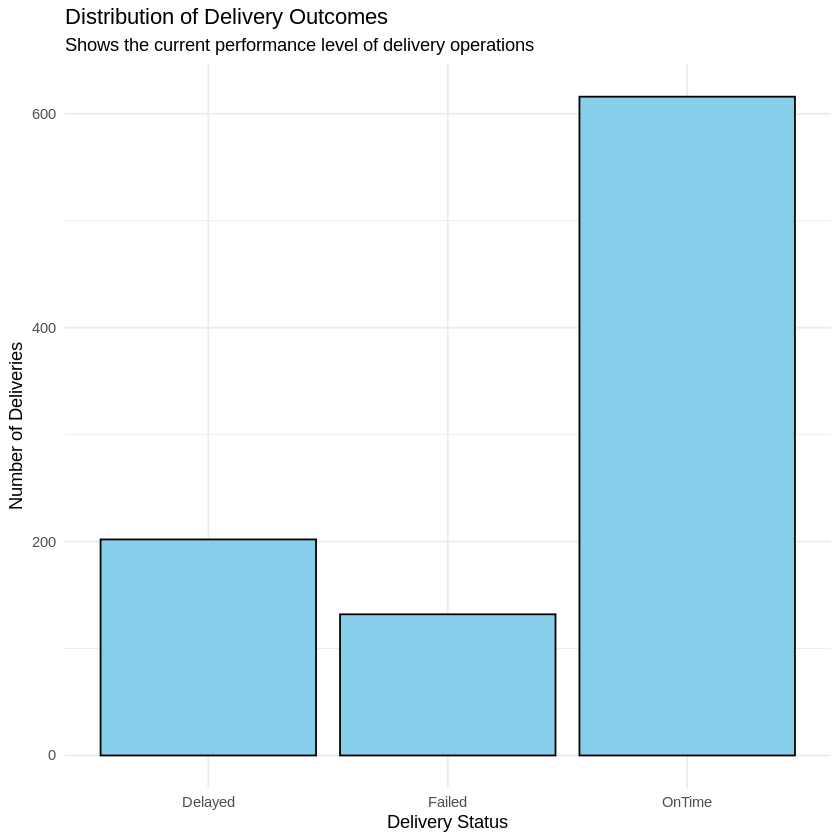

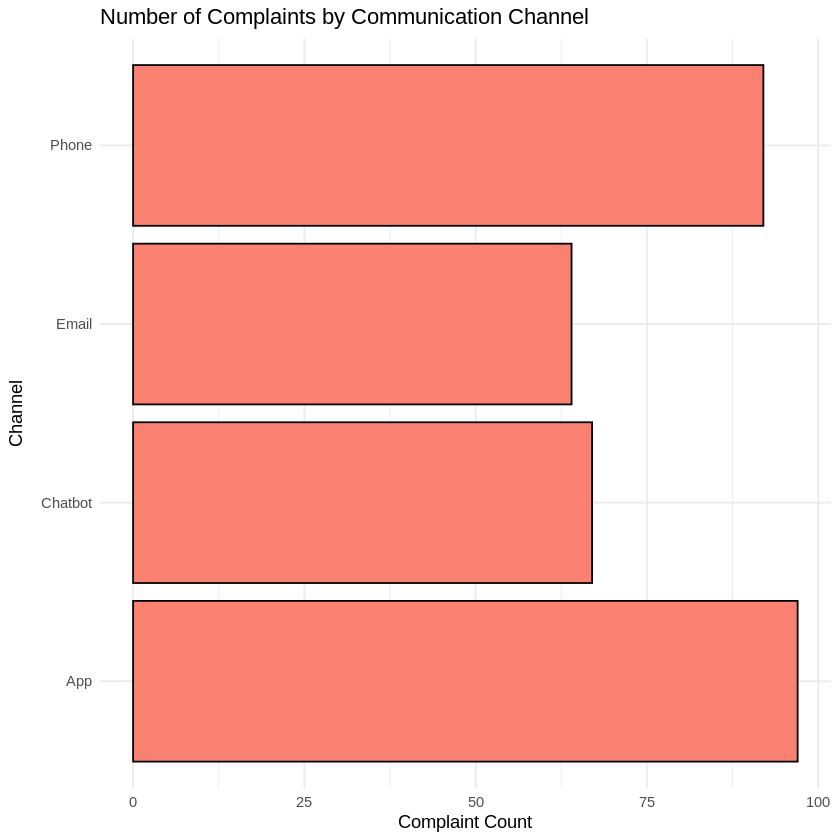

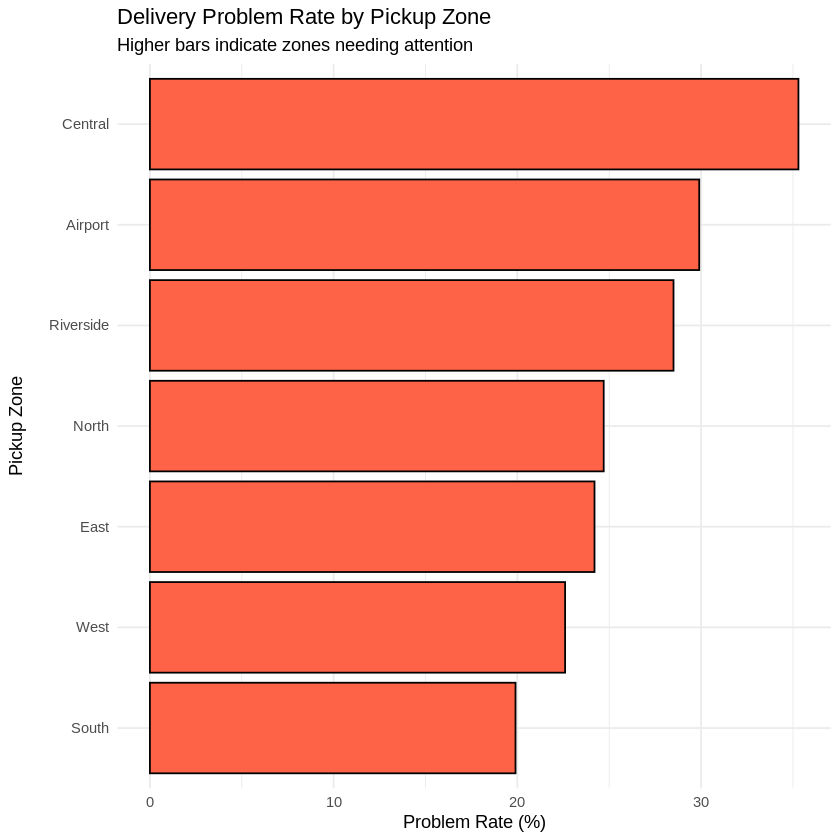

In [12]:
# --------------------------------------------------
# Creating Simple and Clear Visualizations
# --------------------------------------------------

# Chart 1: Delivery Status Distribution
ggplot(deliveries_ready, aes(x = delivery_status)) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Distribution of Delivery Outcomes",
       subtitle = "Shows the current performance level of delivery operations",
       x = "Delivery Status",
       y = "Number of Deliveries") +
  theme_minimal()

# Chart 2: Complaints by Channel
ggplot(complaints_ready, aes(x = channel)) +
  geom_bar(fill = "salmon", color = "black") +
  labs(title = "Number of Complaints by Communication Channel",
       x = "Channel",
       y = "Complaint Count") +
  theme_minimal() +
  coord_flip()

# Chart 3: Problem Rate by Zone
zone_summary <- orders_ready %>%
  left_join(deliveries_ready, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(
    total_orders = n(),
    problems = sum(delivery_status %in% c("Delayed", "Failed"))
  ) %>%
  mutate(problem_rate = round(problems / total_orders * 100, 1))

ggplot(zone_summary, aes(x = reorder(pickup_zone, problem_rate), y = problem_rate)) +
  geom_col(fill = "tomato", color = "black") +
  labs(title = "Delivery Problem Rate by Pickup Zone",
       subtitle = "Higher bars indicate zones needing attention",
       x = "Pickup Zone",
       y = "Problem Rate (%)") +
  theme_minimal() +
  coord_flip()